In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/ecommerce_customer_data_large.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.fillna(0,inplace=True)

In [ ]:
df.shape

(250000, 13)

In [ ]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.405904,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.491067,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,0.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [ ]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [ ]:
df['Average Purchase Value']=df['Total Purchase Amount']/df['Quantity']
df['Age Group']=pd.cut(df['Age'],bins=[0,8,30,45,60,100],labels=['Teen','Young Adult','Adult','Middle Age','Senior'])

In [ ]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Average Purchase Value,Age Group
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0,2427.000000,Adult
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0,816.000000,Adult
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0,2345.000000,Adult
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0,312.333333,Adult
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0,649.500000,Adult


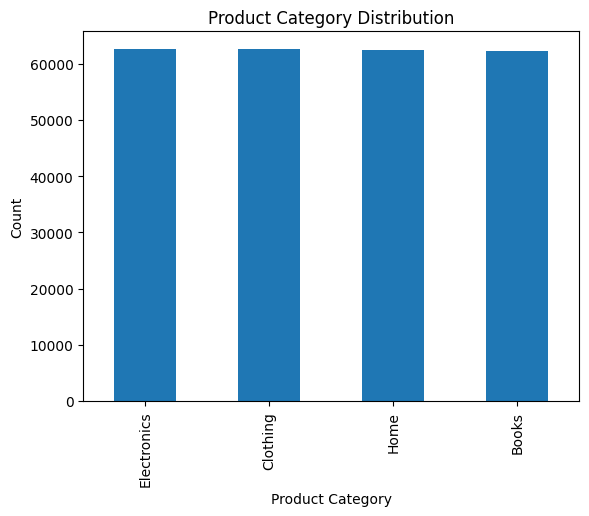

In [ ]:
import matplotlib.pyplot as plt

df['Product Category'].value_counts().plot(kind='bar')

plt.title('Product Category Distribution')
plt.xlabel('Product Category')
plt.ylabel('Count')

plt.show()

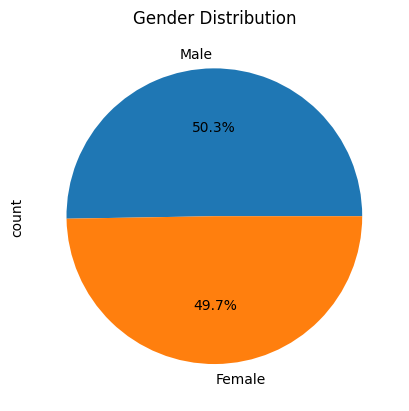

In [ ]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Gender Distribution')

plt.show()

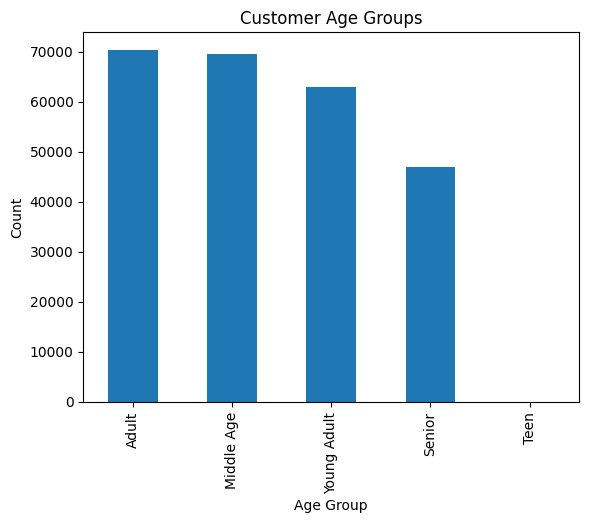

In [ ]:
df['Age Group'].value_counts().plot(kind='bar')

plt.title('Customer Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.show()

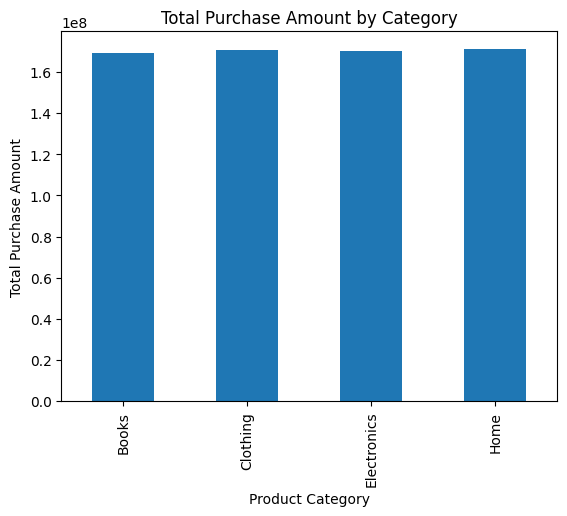

In [ ]:
category_sales = df.groupby('Product Category')['Total Purchase Amount'].sum()

category_sales.plot(kind='bar')

plt.title('Total Purchase Amount by Category')
plt.xlabel('Product Category')
plt.ylabel('Total Purchase Amount')

plt.show()

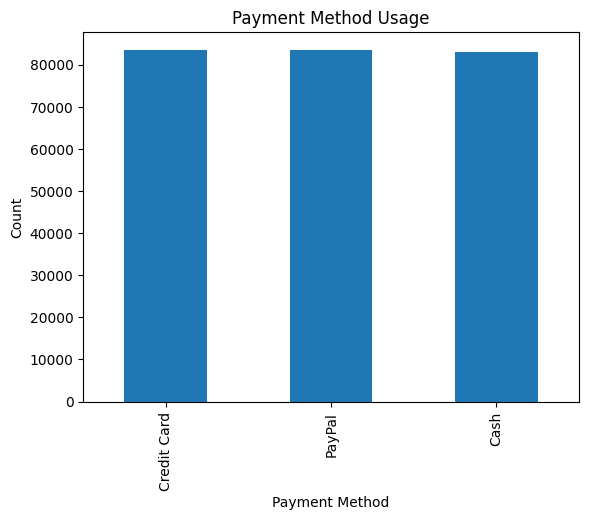

In [ ]:
df['Payment Method'].value_counts().plot(kind='bar')

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Count')

plt.show()

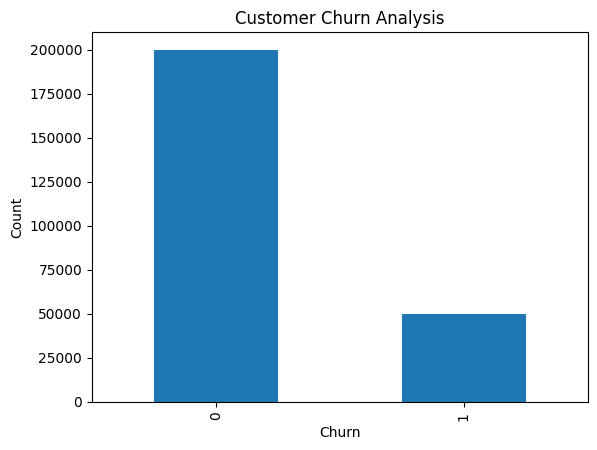

In [ ]:
df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Analysis')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

/tmp/ipykernel_902/2130308948.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spending = df.groupby('Age Group')['Total Purchase Amount'].mean()


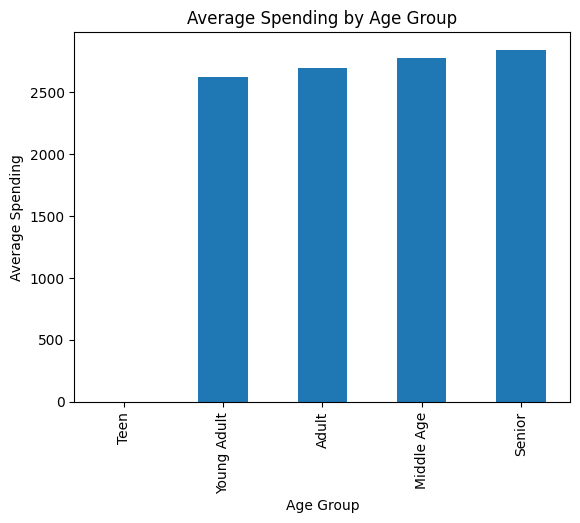

In [ ]:
age_spending = df.groupby('Age Group')['Total Purchase Amount'].mean()

age_spending.plot(kind='bar')

plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Spending')

plt.show()

In [ ]:
df['Customer Segment'] = pd.qcut(
    df['Total Purchase Amount'],
    q=3,
    labels=['Low Value','Medium Value','High Value']
)

df[['Customer Name','Total Purchase Amount','Customer Segment']].head()

,Customer Name,Total Purchase Amount,Customer Segment
0,John Rivera,2427,Medium Value
1,John Rivera,2448,Medium Value
2,John Rivera,2345,Medium Value
3,John Rivera,937,Low Value
4,John Rivera,2598,Medium Value


In [ ]:
segment_profile = df.groupby('Customer Segment').agg({
    'Total Purchase Amount':'mean',
    'Age':'mean',
    'Quantity':'mean'
})

segment_profile

/tmp/ipykernel_902/2239645952.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_profile = df.groupby('Customer Segment').agg({


,Total Purchase Amount,Age,Quantity
Customer Segment,,,
Low Value,1060.159668,43.016856,3.007006
Medium Value,2726.716156,43.801620,3.000468
High Value,4390.338555,44.576848,3.007335


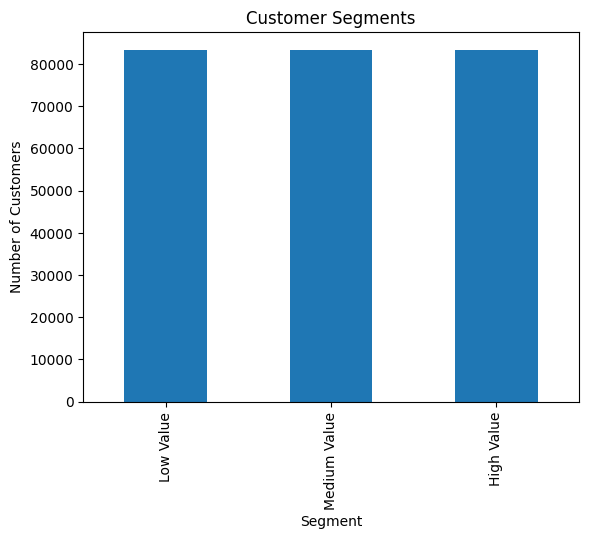

In [ ]:
df['Customer Segment'].value_counts().plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()